In [1]:
from scripts.csv_continue_to_ds_discreet import csv_continue_to_ds_discreet
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from scripts.evaluate_model import evaluate_predictions
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [2]:
X, y = csv_continue_to_ds_discreet()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0, stratify=y)

In [4]:
ratio = sum(y_train == 0) / sum(y_train == 1)

xgb = XGBClassifier(random_state=0, scale_pos_weight=ratio)

In [5]:
scoring_metrics = {
    'roc_auc': 'roc_auc',
    'recall_classe0': make_scorer(recall_score, pos_label=0),
    'recall_classe1': make_scorer(recall_score, pos_label=1),
    'precision_classe0': make_scorer(precision_score, pos_label=0),
    'precision_classe1': make_scorer(precision_score, pos_label=1),
    'f1_classe0': make_scorer(f1_score, pos_label=0),
    'f1_classe1': make_scorer(f1_score, pos_label=1),
}

In [6]:
params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.02, 0.05],
    'max_depth': [2, 3, 4],
    'gamma': [0, 0.1, 0.5],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.2, 0.5, 0.7, 1],
    'reg_lambda': [0, 0.2, 0.5, 0.7, 1],
}

cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

gs = RandomizedSearchCV(xgb, param_distributions=params, cv=cv_stratified, scoring=scoring_metrics, refit='roc_auc', n_jobs=-1, random_state=0, verbose=1, n_iter=400)

In [7]:
gs.fit(X_train, y_train)

Fitting 10 folds for each of 400 candidates, totalling 4000 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,400
,scoring,"{'f1_classe0': make_scorer(f..., pos_label=0), 'f1_classe1': make_scorer(f..., pos_label=1), 'precision_classe0': make_scorer(p..., pos_label=0), 'precision_classe1': make_scorer(p..., pos_label=1), ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [8]:
(f'best_score: {gs.best_score_}; best_params: {gs.best_params_}')

"best_score: 0.8203222644429043; best_params: {'subsample': 0.8, 'reg_lambda': 0.2, 'reg_alpha': 0.2, 'n_estimators': 50, 'min_child_weight': 10, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}"

In [9]:
results = pd.DataFrame(gs.cv_results_)

In [10]:
best_params = {}

In [11]:
for metric in scoring_metrics.keys():
    print(f"Ricerca parametri per la metrica: {metric}")
    best_params[metric] = results.loc[results[f'mean_test_{metric}'].idxmax()]['params']

Ricerca parametri per la metrica: roc_auc
Ricerca parametri per la metrica: recall_classe0
Ricerca parametri per la metrica: recall_classe1
Ricerca parametri per la metrica: precision_classe0
Ricerca parametri per la metrica: precision_classe1
Ricerca parametri per la metrica: f1_classe0
Ricerca parametri per la metrica: f1_classe1


In [12]:
best_params

{'roc_auc': {'subsample': 0.8,
  'reg_lambda': 0.2,
  'reg_alpha': 0.2,
  'n_estimators': 50,
  'min_child_weight': 10,
  'max_depth': 2,
  'learning_rate': 0.01,
  'gamma': 0,
  'colsample_bytree': 0.6},
 'recall_classe0': {'subsample': 0.6,
  'reg_lambda': 0,
  'reg_alpha': 0.5,
  'n_estimators': 150,
  'min_child_weight': 1,
  'max_depth': 4,
  'learning_rate': 0.05,
  'gamma': 0.5,
  'colsample_bytree': 1.0},
 'recall_classe1': {'subsample': 1.0,
  'reg_lambda': 0.5,
  'reg_alpha': 1,
  'n_estimators': 150,
  'min_child_weight': 5,
  'max_depth': 3,
  'learning_rate': 0.02,
  'gamma': 0,
  'colsample_bytree': 0.8},
 'precision_classe0': {'subsample': 0.8,
  'reg_lambda': 1,
  'reg_alpha': 1,
  'n_estimators': 100,
  'min_child_weight': 10,
  'max_depth': 2,
  'learning_rate': 0.02,
  'gamma': 0,
  'colsample_bytree': 0.8},
 'precision_classe1': {'subsample': 1.0,
  'reg_lambda': 0.2,
  'reg_alpha': 0.7,
  'n_estimators': 50,
  'min_child_weight': 10,
  'max_depth': 2,
  'learning_r

In [13]:
def stacking_classifier(X_train, y_train, best_params):
    estimators = [
        ('xgb_roc_auc', XGBClassifier(**best_params['roc_auc'])),
        ('xgb_recall_0', XGBClassifier(**best_params['recall_classe0'])),
        ('xgb_recall_1', XGBClassifier(**best_params['recall_classe1'])),
        ('xgb_precision_0', XGBClassifier(**best_params['precision_classe0'])),
        ('xgb_precision_1', XGBClassifier(**best_params['precision_classe1'])),
        ('xgb_f1_0', XGBClassifier(**best_params['f1_classe0'])),
        ('xgb_f1_1', XGBClassifier(**best_params['f1_classe1']))
    ]
    
    final_estimator = LogisticRegression(random_state=0, class_weight='balanced')
    stacking_clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
    
    param_grid_meta = [
    {
        'final_estimator__solver': ['liblinear', 'saga'],
        'final_estimator__penalty': ['l1', 'l2'],
        'final_estimator__C': [0.01, 0.1, 1, 10, 100],
        'final_estimator__max_iter': [1000, 2000, 3000],
    },
    {
        'final_estimator__solver': ['lbfgs', 'sag'],
        'final_estimator__penalty': ['l2'],
        'final_estimator__C': [0.01, 0.1, 1, 10, 100],
        'final_estimator__max_iter': [1000, 2000, 3000],
    },
    {
        'final_estimator__solver': ['lbfgs', 'sag'],
        'final_estimator__penalty': ['none'],
        'final_estimator__C': [0.01, 0.1, 1, 10, 100],
        'final_estimator__max_iter': [1000, 2000, 3000],
    }
]
    
    cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    meta_search = RandomizedSearchCV(
        stacking_clf,
        param_distributions=param_grid_meta,
        n_iter=300,
        cv=cv_stratified,
        scoring='roc_auc',
        random_state=0
    )
    
    meta_search.fit(X_train, y_train)
    
    return meta_search.best_estimator_

In [14]:
trained_model = stacking_classifier(X_train, y_train, best_params)

c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 120 is smaller than n_iter=300. Running 120 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\sklearn\linear_mode

In [15]:
def evaluate_on_train_test_ensemble(models, X_train, y_train, X_test, y_test, threshold=0.5):
    print ("Evaluating on training set")
    train_pred = models.predict(X_train)
    train_proba = models.predict_proba(X_train)[:, 1]
    evaluate_predictions(train_pred, y_train, train_proba, model_name="Ensemble Training Set")
    
    print("Evaluating on test set")
    test_pred = models.predict(X_test)
    test_proba = models.predict_proba(X_test)[:, 1]
    evaluate_predictions(test_pred, y_test, test_proba, model_name="Ensemble Test Set")


Evaluating on training set


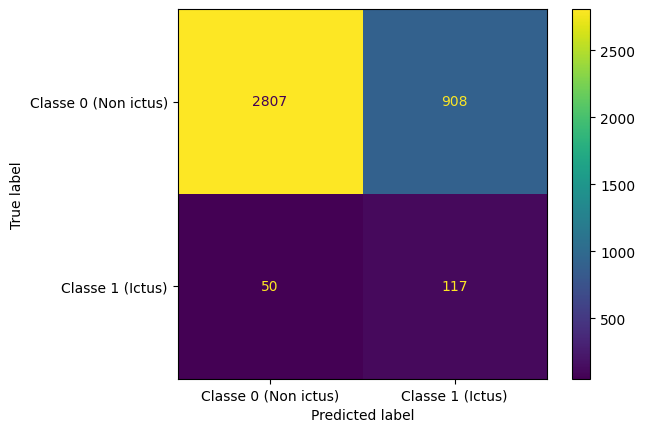

Percentuale di veri negativi: 75.56%
Percentuale di veri positivi: 70.06%
                      precision    recall  f1-score   support

Classe 0 (Non ictus)       0.98      0.76      0.85      3715
    Classe 1 (Ictus)       0.11      0.70      0.20       167

            accuracy                           0.75      3882
           macro avg       0.55      0.73      0.53      3882
        weighted avg       0.95      0.75      0.83      3882

[[2807  908]
 [  50  117]]


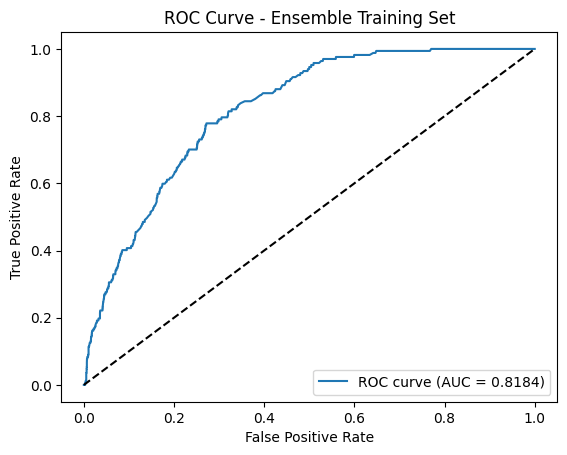

Evaluating on test set


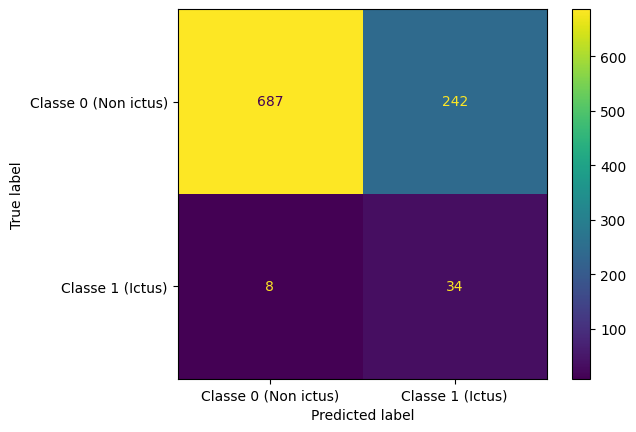

Percentuale di veri negativi: 73.95%
Percentuale di veri positivi: 80.95%
                      precision    recall  f1-score   support

Classe 0 (Non ictus)       0.99      0.74      0.85       929
    Classe 1 (Ictus)       0.12      0.81      0.21        42

            accuracy                           0.74       971
           macro avg       0.56      0.77      0.53       971
        weighted avg       0.95      0.74      0.82       971

[[687 242]
 [  8  34]]


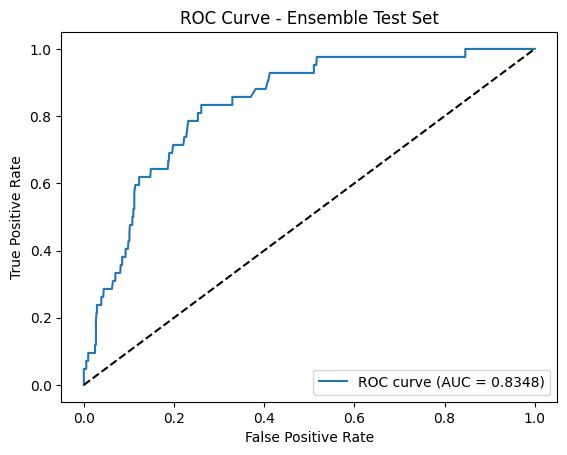

In [16]:
evaluate_on_train_test_ensemble(trained_model, X_train, y_train, X_test, y_test)